# Employee Attrition Analysis

**Author:** Tshipfuralo Leigh Funyufunyu

## 📋Project Overview

This project analyzes the IBM HR Employee Attrition dataset to identify the factors that contribute to employee attrition. The analysis aims to provide data-driven insights and recommendations that can help the Human Resources (HR) department improve employee retention and reduce employee turnover.

## 🎯Business Questions

This analysis aims to answer the following business questions:

1. What is the overall employee attrition rate?
2. Which employee characteristics are associated with higher attrition?
3. Does monthly income influence employee attrition?
4. Does working overtime increase employee attrition?
5. How does job satisfaction relate to employee attrition?
6. Which departments and job roles experience the highest attrition?
7. What recommendations can help reduce employee turnover?

---
# 1. 💼Business Understanding

## ⚠️Business Problem

The company is experiencing employee attrition and wants to understand why employees are leaving.

## Business Objective

Identify the factors that contribute to employee attrition and provide data-driven recommendations to help improve employee retention.

## 💡Why This Matters

Employee attrition increases recruitment and training costs, reduces productivity, places additional workload on existing employees, and results in the loss of valuable skills and experience.

## Primary Stakeholder

Human Resources (HR) Department


---
# 2. 📂Dataset Understanding

In this section, we will:

- Load the dataset.
- Verify that it loaded correctly.
- Understand its structure.
- Identify the variables available for analysis.

### 2.1 Load Dataset

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("attrition_project.csv")


In [29]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


The first five rows show that each record represents an individual employee and contains information about demographics, job details, compensation, satisfaction levels, and attrition status.

### 2.2 Dataset Size

In [30]:
df.shape

(1470, 35)

### 2.3 Explore Variables

In [31]:
for column in df.columns:
    print(f"{column}: Number of unique values {df[column].nunique()}")
    print("---------------------------------------------------------")

Age: Number of unique values 43
---------------------------------------------------------
Attrition: Number of unique values 2
---------------------------------------------------------
BusinessTravel: Number of unique values 3
---------------------------------------------------------
DailyRate: Number of unique values 886
---------------------------------------------------------
Department: Number of unique values 3
---------------------------------------------------------
DistanceFromHome: Number of unique values 29
---------------------------------------------------------
Education: Number of unique values 5
---------------------------------------------------------
EducationField: Number of unique values 6
---------------------------------------------------------
EmployeeCount: Number of unique values 1
---------------------------------------------------------
EmployeeNumber: Number of unique values 1470
---------------------------------------------------------
EnvironmentSatisfactio

The dataset contains a mixture of numerical and categorical variables describing employee characteristics, job information, and workplace conditions.

The analysis identified:

Variables with many unique values, such as EmployeeNumber and DailyRate.
Categorical variables with fewer groups, such as Department, BusinessTravel, and JobRole.
Binary variables such as Attrition and Gender.
Constant variables such as EmployeeCount, which contain no variation.

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

The dataset has no missing values, as all columns contain 1,470 non-null records.

---
# 3. 🧹Data Cleaning


In [ ]:
# Check Missing Values
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [ ]:
# Check duplicate RECORDS

df.duplicated().sum()

np.int64(0)

In [19]:
# Identify columns with only one unique value

for column in df.columns:
    if df[column].nunique() == 1:
        print(column)

EmployeeCount
Over18
StandardHours


### 📝 Data Cleaning Summary

The dataset was evaluated for missing values, duplicate records, and unnecessary features.

The following checks were performed:

- **Missing values:** No missing values were detected across the 35 columns. All 1,470 employee records contained complete information.
- **Duplicate records:** No duplicate employee records were identified, ensuring that each employee contributes only once to the analysis.
- **Constant features:** Three columns (`EmployeeCount`, `Over18`, and `StandardHours`) contained only one unique value and provided no meaningful variation for analysis. These columns were removed.
- **Employee identifier:** `EmployeeNumber` was removed because it serves only as a unique identifier and does not describe an employee characteristic that can explain attrition.

The analysis identified four columns that do not provide meaningful information for understanding employee attrition.

- `EmployeeCount`, `Over18`, and `StandardHours` contained only one unique value, meaning they had no variation across employees.
- `EmployeeNumber` contained a unique identifier for each employee but did not represent any employee characteristic.

Since these features do not contribute to explaining employee turnover, they were removed from the dataset.


In [ ]:
df = df.drop(columns=[ 'EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], errors='ignore')

In [26]:
df.shape

(1470, 31)

---
# 4. 📊Exploratory Data Analysis (EDA)

## 4.1 Attrition Overview
Understand the distribution of employees who left the company compared to employees who remained.

In [33]:
# Count employees by attrition status

df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [34]:
# Calculate attrition percentage

df['Attrition'].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


Most employees remained with the company, with 83.88% classified as retained.

However, 16.12% of employees left the company. This indicates that employee turnover exists within the organization and requires further investigation to understand the factors contributing to attrition.
Understanding the reasons behind employee departures can help HR develop strategies to improve retention and reduce the costs associated with replacing employees.


## 📈 Visualization: Employee Attrition Distribution

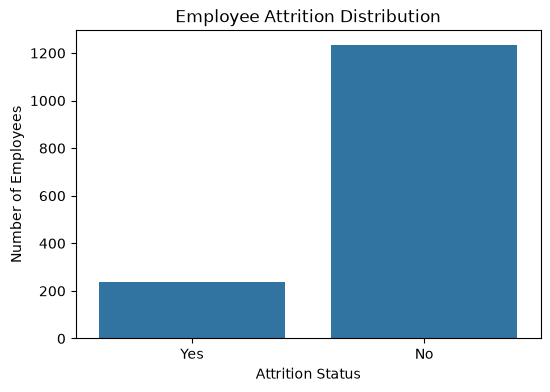

In [36]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Attrition')

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition Status")
plt.ylabel("Number of Employees")

plt.show()

## 4.2 Overtime vs Attrition

Business Question:

Does overtime increase the likelihood of employee attrition?

In [40]:
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


In [39]:
pd.crosstab(df['OverTime'], df['Attrition'])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


The attrition rate differs significantly between employees who work overtime and those who do not.

- Employees who do not work overtime had an attrition rate of **10.44%**.
- Employees who work overtime had an attrition rate of **30.53%**.

Employees working overtime are almost three times more likely to leave the company compared to employees who do not work overtime.

This suggests that overtime may be associated with increased employee turnover.

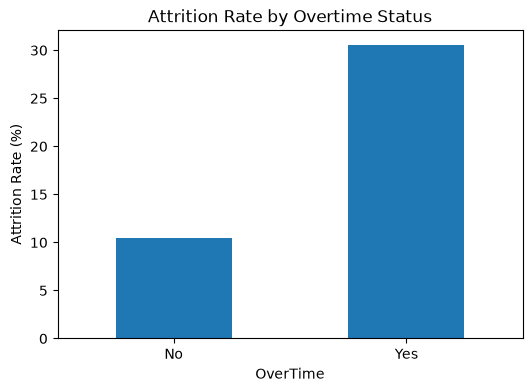

In [41]:
overtime_attrition = pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
) * 100

# Plot employees who left (Attrition = Yes)

overtime_attrition['Yes'].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Attrition Rate by Overtime Status")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.show()

## 4.3 Department vs Attrition
Business Question:

Which departments experience the highest employee attrition?

In [42]:
department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

department_attrition

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


The attrition rate differs across departments:

- Sales has the highest attrition rate at **20.63%**.
- Human Resources follows with an attrition rate of **19.05%**.
- Research & Development has the lowest attrition rate at **13.84%**.

The analysis shows that employees in the Sales department leave at a higher rate compared to other departments.

Research & Development has the lowest attrition rate, suggesting that employee retention is stronger within this department.

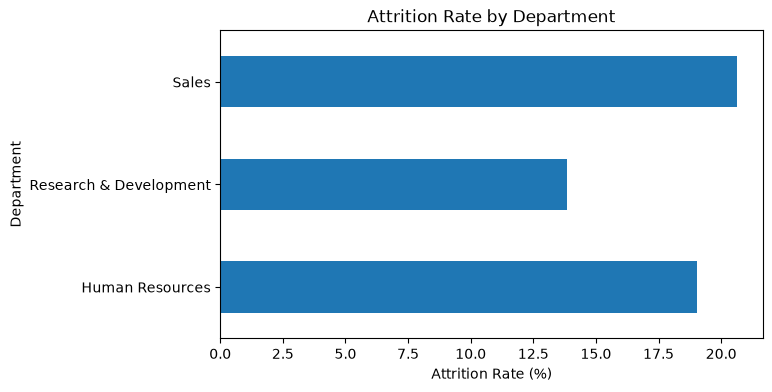

In [46]:
department_attrition['Yes'].plot(
    kind='barh',
    figsize=(7,4)
)

plt.title("Attrition Rate by Department")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Department")

plt.show()

## 4.4 Job Role vs Attrition
Business Question:

Are certain job roles more likely to experience employee attrition?

In [47]:
jobrole_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
) * 100

jobrole_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


Attrition rates vary considerably across different job roles.

The highest attrition was observed among **Sales Representatives (39.76%)**, followed by **Laboratory Technicians (23.94%)** and **Human Resources employees (23.08%)**.

The lowest attrition rates were observed among **Research Directors (2.50%)**, **Managers (4.90%)**, and **Healthcare Representatives (6.87%)**.

Job roles show noticeable differences in employee turnover.

Sales Representatives experience a much higher attrition rate compared to other roles, suggesting that factors such as workload, job demands, or career opportunities may differ across positions.

Further investigation is needed to understand why certain roles experience higher employee turnover.

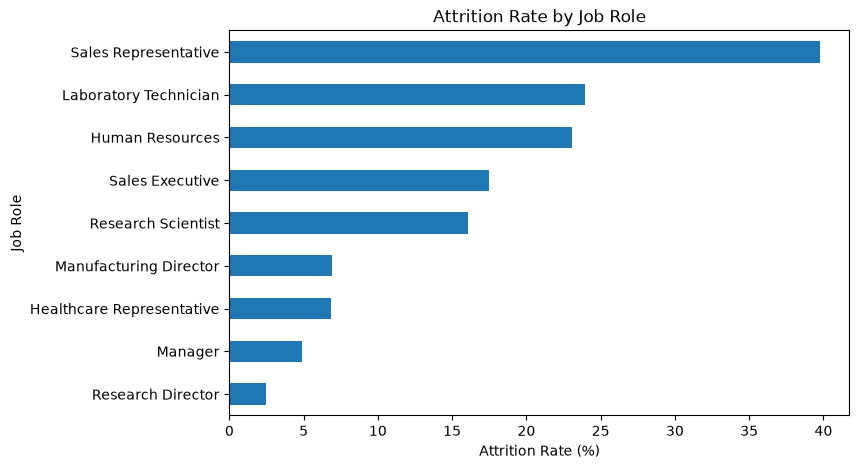

In [48]:
plt.figure(figsize=(8,5))

jobrole_attrition['Yes'].sort_values().plot(
    kind='barh'
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.show()

## 4.5 Monthly Income vs Attrition
Business Question:

Does salary influence employee attrition?

In [49]:
df.groupby('Attrition')['MonthlyIncome'].mean()

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64


The average monthly income differs between employees who remained with the company and those who left.

Employees who stayed had an average monthly income of approximately **6,832.74**, while employees who left had an average monthly income of approximately **4,787.09**.

Employees who left the company had a lower average monthly income compared to employees who stayed.

This suggests that compensation may be associated with employee retention; however, salary alone may not explain attrition, as other factors such as job role, satisfaction, and workload may also influence an employee's decision to leave.

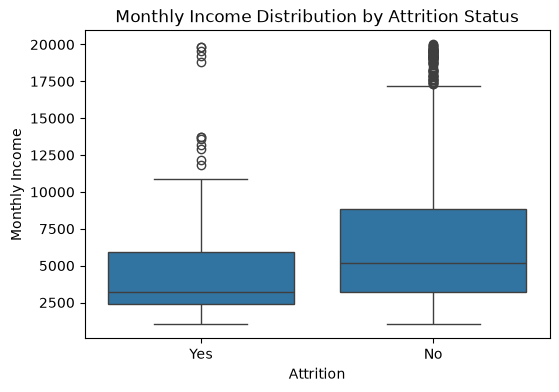

In [50]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x='Attrition',
    y='MonthlyIncome'
)

plt.title("Monthly Income Distribution by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

## 4.6 Job Satisfaction vs Attrition

Business Question:

Does job satisfaction affect employee retention?

In [51]:
satisfaction_attrition = pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition'],
    normalize='index'
) * 100

satisfaction_attrition

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


Attrition rates differ across job satisfaction levels.

Employees with the lowest job satisfaction level (1) had the highest attrition rate at **22.84%**, while employees with the highest satisfaction level (4) had the lowest attrition rate at **11.33%**.

The results show a relationship between job satisfaction and employee attrition.

Employees with lower satisfaction levels are more likely to leave the company, while higher satisfaction levels are associated with better employee retention.


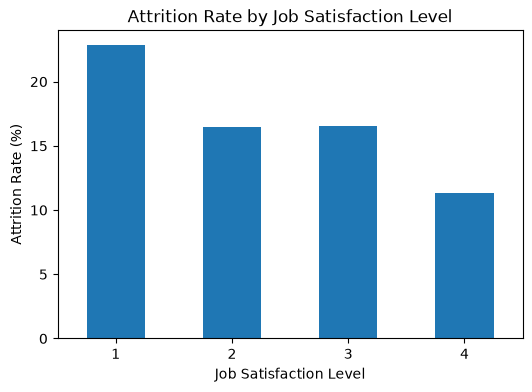

In [52]:
plt.figure(figsize=(6,4))

satisfaction_attrition['Yes'].plot(
    kind='bar'
)

plt.title("Attrition Rate by Job Satisfaction Level")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.show()

## 4.7 Work-Life Balance vs Attrition

Business Question:

Does work-life balance influence employee turnover?

In [53]:
worklife_attrition = pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition'],
    normalize='index'
) * 100

worklife_attrition

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


Attrition rates vary across different work-life balance levels.

Employees with the lowest work-life balance level (1) recorded the highest attrition rate at **31.25%**, while employees with a better work-life balance generally showed lower attrition rates.

The results suggest that poor work-life balance may contribute to employee attrition.

Employees with the lowest work-life balance rating have a noticeably higher likelihood of leaving compared to employees with better ratings. However, the highest work-life balance category does not have the lowest attrition rate, suggesting that other factors may also influence employee retention.

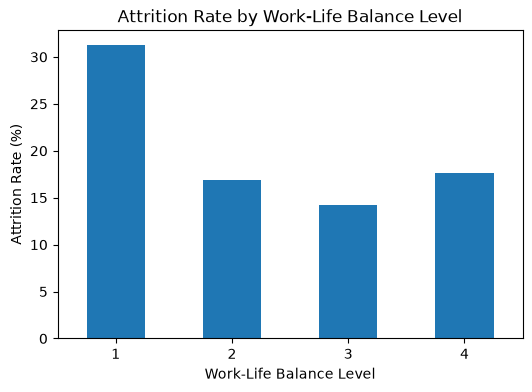

In [55]:
plt.figure(figsize=(6,4))

worklife_attrition['Yes'].plot(
    kind='bar'
)

plt.title("Attrition Rate by Work-Life Balance Level")
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.show()

## 4.8 DistanceFromHome vs Attrition

Business Question:

Does commuting distance influence employee attrition?

In [56]:
df.groupby('Attrition')['DistanceFromHome'].mean()

Attrition
No      8.915653
Yes    10.632911
Name: DistanceFromHome, dtype: float64

The average distance from home differs slightly between employees who stayed and those who left.

Employees who remained with the company lived an average of **8.92** units from work, while employees who left lived an average of **10.63** units from work.

Employees who left the company lived slightly farther from the workplace on average than those who stayed.

This suggests that commuting distance may have some influence on employee attrition, although the difference is relatively small and should be considered alongside other factors.

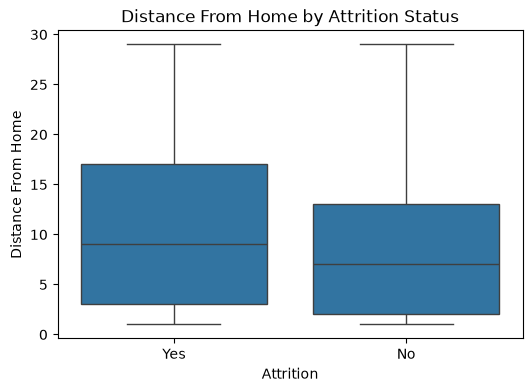

In [57]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x='Attrition',
    y='DistanceFromHome'
)

plt.title("Distance From Home by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Distance From Home")

plt.show()

---
# 5. Analysis & Findings

## 📊 Key Findings

The analysis identified several factors associated with employee attrition:

- The overall employee attrition rate is **16.12%**, indicating that approximately one in six employees left the company.

- Employees who worked overtime experienced a substantially higher attrition rate (**30.53%**) than employees who did not (**10.44%**).

- The **Sales** department recorded the highest attrition rate (**20.63%**), while **Research & Development** had the lowest (**13.84%**).

- **Sales Representatives** had the highest attrition rate (**39.76%**), whereas **Research Directors** had the lowest (**2.50%**).

- Employees who left earned a lower average monthly income (**4,787.09**) than employees who remained (**6,832.74**).

- Lower job satisfaction was associated with higher attrition, with employees at the lowest satisfaction level showing the highest attrition rate (**22.84%**).

- Employees reporting the poorest work-life balance had the highest attrition rate (**31.25%**).

- Employees who left lived slightly farther from work on average (**10.63**) than employees who stayed (**8.92**).


## 📝 Overall Finding

The analysis suggests that employee attrition is influenced by multiple factors rather than a single cause. Overtime, job role, work-life balance, job satisfaction, and monthly income show the strongest associations with employees leaving the company. Department and commuting distance also appear to contribute, although their relationships with attrition are less pronounced.

---
# 6. Conclusion

The analysis found that employee attrition is influenced by several workplace factors rather than a single issue. Employees who worked overtime, earned lower monthly incomes, reported lower job satisfaction, and experienced poorer work-life balance were more likely to leave the company. Higher attrition was also observed in specific departments and job roles, indicating that turnover is not evenly distributed across the organization.

These findings suggest that improving employee retention will require targeted strategies that address workload, employee well-being, compensation, and the specific challenges faced by high-risk departments and job roles.

---

# 7. Recommendations💡

Based on the findings of this analysis, the following recommendations are proposed to help reduce employee attrition:

1. **Reduce excessive overtime**
   - Review workloads and staffing levels to minimize excessive overtime, as employees working overtime recorded substantially higher attrition rates.

2. **Review compensation strategies**
   - Assess salary structures, particularly for lower-paid positions, to ensure employees are fairly compensated and remain competitive within the industry.

3. **Improve employee satisfaction**
   - Conduct regular employee engagement surveys and implement initiatives that enhance job satisfaction, career development, and workplace recognition.

4. **Promote work-life balance**
   - Introduce flexible work arrangements, wellness programs, or leave policies that support a healthier balance between work and personal life.

5. **Focus retention efforts on high-risk job roles and departments**
   - Prioritize retention strategies for roles and departments with higher attrition rates, such as **Sales Representatives** and the **Sales** department.

6. **Monitor employee retention regularly**
   - Track attrition trends over time and use data analytics to identify emerging risks and evaluate the effectiveness of retention initiatives.

   ---

# 8. 📄Presentation Summary

## Executive Summary

This project analyzed employee attrition data to identify the key factors associated with employees leaving the company and to provide data-driven recommendations for improving employee retention.

The analysis found an overall attrition rate of **16.12%**, with overtime, lower monthly income, lower job satisfaction, and poor work-life balance showing the strongest associations with employee turnover. Higher attrition rates were also observed in the **Sales** department and among **Sales Representatives**, indicating that employee turnover is concentrated in specific areas of the organization rather than affecting all employees equally.

Based on these findings, the recommended actions include reducing excessive overtime, reviewing compensation for lower-paid roles, improving employee satisfaction and work-life balance, and implementing targeted retention strategies for high-risk departments and job roles. These initiatives can help the organization improve employee retention and reduce the costs associated with workforce turnover.

---

# End of Analysis

---
